# Phase 7 — Hyperparameter Tuning

This notebook performs a small, controlled hyperparameter search for the selected
ResNet18 transfer-learning configuration.

Each experiment changes only one of:

- learning rate
- dropout
- weight decay

Model selection uses **validation Macro F1**. The training split is used to fit the
models, and the validation split is used to compare configurations.

> The test split is deliberately not loaded, referenced, or evaluated in this notebook.

In [1]:
from __future__ import annotations

import gc
import json
import os
import random
import shutil
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate

        marker_count = sum(
            (candidate / marker).exists()
            for marker in ["src", "data", "results", "notebooks"]
        )

        if marker_count >= 3:
            return candidate

    return start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from src.datasets.horse_dataset import HorseGrimaceDataset
from src.training.losses import create_classification_loss
from src.training.trainer import Trainer

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")

Project root: /home/uteam6/computer-vision-equine-grimace-scale
PyTorch version: 2.5.1+cu121


In [2]:
SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {DEVICE}")
print(f"Random seed: {SEED}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
Random seed: 42
GPU: Quadro RTX 4000


In [3]:
TRAIN_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "train.csv"
)

VALIDATION_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "validation.csv"
)

PHASE_5_METADATA_PATH = (
    PROJECT_ROOT
    / "results"
    / "transfer_learning"
    / "best_transfer_model.json"
)

PHASE_6_SELECTION_PATH = (
    PROJECT_ROOT
    / "results"
    / "model_comparison"
    / "final_model.json"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "hyperparameter_tuning"
)

CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
HISTORIES_DIR = RESULTS_DIR / "histories"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"

FINAL_MODEL_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_model"
)

for directory in [
    RESULTS_DIR,
    CHECKPOINTS_DIR,
    HISTORIES_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    FINAL_MODEL_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

assert TRAIN_CSV.exists(), f"Missing file: {TRAIN_CSV}"
assert VALIDATION_CSV.exists(), (
    f"Missing file: {VALIDATION_CSV}"
)

print(f"Training CSV:   {TRAIN_CSV}")
print(f"Validation CSV: {VALIDATION_CSV}")
print(f"Results folder: {RESULTS_DIR}")
print("\nThe test CSV is not defined in this notebook.")

Training CSV:   /home/uteam6/computer-vision-equine-grimace-scale/data/splits/train.csv
Validation CSV: /home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv
Results folder: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning

The test CSV is not defined in this notebook.


In [4]:
def read_json(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {}

    with path.open("r", encoding="utf-8") as input_file:
        return json.load(input_file)


phase_5_metadata = read_json(
    PHASE_5_METADATA_PATH
)

print("Phase 5 metadata:")
display(phase_5_metadata)

raw_training_mode = str(
    phase_5_metadata.get(
        "training_mode",
        phase_5_metadata.get(
            "selected_training_mode",
            "fine_tuned",
        ),
    )
).lower()

if "frozen" in raw_training_mode:
    TRAINING_MODE = "frozen"
else:
    TRAINING_MODE = "fine_tuned"

print(f"Selected ResNet18 training mode: {TRAINING_MODE}")

Phase 5 metadata:


{'architecture': 'resnet18',
 'training_mode': 'fine_tuned',
 'num_classes': 3,
 'dropout_rate': 0.5,
 'pretrained_weights': 'ResNet18_Weights.DEFAULT',
 'augmentation': 'random_crop',
 'normalization': 'imagenet',
 'image_size': 224,
 'resize_size': 256,
 'class_names': ['Pain Score 0', 'Pain Score 1', 'Pain Score 2'],
 'class_weights': [0.5353661066168844, 1.5501501501501502, 2.053301511535402],
 'selection_metric': 'validation_macro_f1',
 'selection_metric_value': 0.6975608834302688,
 'source_checkpoint': '/home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/checkpoints/resnet18_finetuned_best.pth',
 'source_history': '/home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/histories/resnet18_finetuned_history.csv',
 'validation_metrics': {'architecture': 'resnet18',
  'training_mode': 'fine_tuned',
  'num_classes': 3,
  'dropout_rate': 0.5,
  'pretrained_weights': 'ResNet18_Weights.DEFAULT',
  'augmentation': 'random_crop',
  'normalizatio

Selected ResNet18 training mode: fine_tuned


In [5]:
train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)

required_columns = {
    "image_path",
    "pain_score",
}

for split_name, dataframe in [
    ("training", train_df),
    ("validation", validation_df),
]:
    missing_columns = required_columns.difference(
        dataframe.columns
    )

    assert not missing_columns, (
        f"{split_name.title()} CSV is missing: "
        f"{sorted(missing_columns)}"
    )

NUM_CLASSES = 3
CLASS_NAMES = [
    "No Pain",
    "Moderate Pain",
    "Severe Pain",
]

train_labels = (
    train_df["pain_score"]
    .astype(int)
    .to_numpy()
)

class_indices = np.arange(NUM_CLASSES)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=train_labels,
)

CLASS_WEIGHTS = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
)

print(f"Training samples:   {len(train_df):,}")
print(f"Validation samples: {len(validation_df):,}")

distribution_df = pd.DataFrame(
    {
        "training": (
            train_df["pain_score"]
            .value_counts()
            .sort_index()
        ),
        "validation": (
            validation_df["pain_score"]
            .value_counts()
            .sort_index()
        ),
        "class_weight": class_weights_array,
    }
)

display(distribution_df)

Training samples:   2,581
Validation samples: 315


,training,validation,class_weight
pain_score,,,
0,1607,203,0.535366
1,555,67,1.550150
2,419,45,2.053302


In [6]:
IMAGE_SIZE = 224
RESIZE_SIZE = 256

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]

train_transform = transforms.Compose(
    [
        transforms.Resize(
            (RESIZE_SIZE, RESIZE_SIZE)
        ),
        transforms.RandomCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

validation_transform = transforms.Compose(
    [
        transforms.Resize(
            (RESIZE_SIZE, RESIZE_SIZE)
        ),
        transforms.CenterCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

print("Training transform:")
print(train_transform)

print("\nValidation transform:")
print(validation_transform)

Training transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = DEVICE.type == "cuda"


def create_dataloaders(
    seed: int = SEED,
) -> tuple[DataLoader, DataLoader]:
    train_dataset = HorseGrimaceDataset(
        csv_file=TRAIN_CSV,
        image_root=PROJECT_ROOT,
        transform=train_transform,
        verify_images=True,
    )

    validation_dataset = HorseGrimaceDataset(
        csv_file=VALIDATION_CSV,
        image_root=PROJECT_ROOT,
        transform=validation_transform,
        verify_images=True,
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        generator=generator,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )

    return train_loader, validation_loader


inspection_train_loader, inspection_validation_loader = (
    create_dataloaders()
)

batch = next(iter(inspection_train_loader))

print(f"Training batches:   {len(inspection_train_loader)}")
print(
    "Validation batches:",
    len(inspection_validation_loader),
)
print(f"Image batch shape:  {batch['image'].shape}")
print(f"Label batch shape:  {batch['pain_score'].shape}")

del inspection_train_loader
del inspection_validation_loader
del batch

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Training batches:   81
Validation batches: 10
Image batch shape:  torch.Size([32, 3, 224, 224])
Label batch shape:  torch.Size([32])


In [8]:
@dataclass(frozen=True)
class TuningConfiguration:
    experiment_id: str
    learning_rate: float
    dropout: float
    weight_decay: float
    changed_parameter: str


# One-factor-at-a-time search around the Phase 5 defaults.
# This gives seven controlled experiments rather than a large grid.
TUNING_CONFIGURATIONS = [
    TuningConfiguration(
        experiment_id="config_01_reference",
        learning_rate=1e-3,
        dropout=0.5,
        weight_decay=1e-4,
        changed_parameter="reference",
    ),
    TuningConfiguration(
        experiment_id="config_02_lr_low",
        learning_rate=3e-4,
        dropout=0.5,
        weight_decay=1e-4,
        changed_parameter="learning_rate",
    ),
    TuningConfiguration(
        experiment_id="config_03_lr_high",
        learning_rate=3e-3,
        dropout=0.5,
        weight_decay=1e-4,
        changed_parameter="learning_rate",
    ),
    TuningConfiguration(
        experiment_id="config_04_dropout_low",
        learning_rate=1e-3,
        dropout=0.3,
        weight_decay=1e-4,
        changed_parameter="dropout",
    ),
    TuningConfiguration(
        experiment_id="config_05_dropout_high",
        learning_rate=1e-3,
        dropout=0.7,
        weight_decay=1e-4,
        changed_parameter="dropout",
    ),
    TuningConfiguration(
        experiment_id="config_06_no_weight_decay",
        learning_rate=1e-3,
        dropout=0.5,
        weight_decay=0.0,
        changed_parameter="weight_decay",
    ),
    TuningConfiguration(
        experiment_id="config_07_weight_decay_high",
        learning_rate=1e-3,
        dropout=0.5,
        weight_decay=1e-3,
        changed_parameter="weight_decay",
    ),
]

configuration_df = pd.DataFrame(
    [
        asdict(configuration)
        for configuration in TUNING_CONFIGURATIONS
    ]
)

display(configuration_df)

,experiment_id,learning_rate,dropout,weight_decay,changed_parameter
0,config_01_reference,0.0010,0.5,0.0001,reference
1,config_02_lr_low,0.0003,0.5,0.0001,learning_rate
2,config_03_lr_high,0.0030,0.5,0.0001,learning_rate
3,config_04_dropout_low,0.0010,0.3,0.0001,dropout
4,config_05_dropout_high,0.0010,0.7,0.0001,dropout
5,config_06_no_weight_decay,0.0010,0.5,0.0000,weight_decay
6,config_07_weight_decay_high,0.0010,0.5,0.0010,weight_decay


In [9]:
def build_resnet18(
    dropout: float,
    training_mode: str,
) -> nn.Module:
    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(
            in_features,
            NUM_CLASSES,
        ),
    )

    if training_mode == "frozen":
        for parameter in model.parameters():
            parameter.requires_grad = False

        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    elif training_mode == "fine_tuned":
        for parameter in model.parameters():
            parameter.requires_grad = True

    else:
        raise ValueError(
            f"Unsupported training mode: {training_mode}"
        )

    return model


def create_optimizer(
    model: nn.Module,
    configuration: TuningConfiguration,
) -> torch.optim.Optimizer:
    if TRAINING_MODE == "frozen":
        return torch.optim.Adam(
            model.fc.parameters(),
            lr=configuration.learning_rate,
            weight_decay=configuration.weight_decay,
        )

    backbone_parameters = [
        parameter
        for name, parameter in model.named_parameters()
        if not name.startswith("fc.")
    ]

    head_parameters = list(
        model.fc.parameters()
    )

    return torch.optim.Adam(
        [
            {
                "params": backbone_parameters,
                "lr": (
                    configuration.learning_rate
                    * 0.1
                ),
            },
            {
                "params": head_parameters,
                "lr": configuration.learning_rate,
            },
        ],
        weight_decay=configuration.weight_decay,
    )


def safe_torch_load(
    path: Path,
    map_location: torch.device | str,
) -> Any:
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


def extract_state_dict(
    checkpoint: Any,
) -> dict[str, torch.Tensor]:
    if isinstance(checkpoint, nn.Module):
        return checkpoint.state_dict()

    if not isinstance(checkpoint, dict):
        raise TypeError(
            "Unsupported checkpoint type: "
            f"{type(checkpoint)}"
        )

    for key in [
        "model_state_dict",
        "state_dict",
        "best_model_state_dict",
        "network_state_dict",
    ]:
        value = checkpoint.get(key)

        if isinstance(value, dict):
            return value

    if checkpoint and all(
        torch.is_tensor(value)
        for value in checkpoint.values()
    ):
        return checkpoint

    raise KeyError(
        "No model state dictionary was found. "
        f"Checkpoint keys: {list(checkpoint.keys())}"
    )


def load_checkpoint_into_model(
    model: nn.Module,
    checkpoint_path: Path,
) -> dict[str, Any]:
    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=DEVICE,
    )

    state_dict = extract_state_dict(
        checkpoint
    )

    model.load_state_dict(
        state_dict,
        strict=True,
    )

    if isinstance(checkpoint, dict):
        return checkpoint

    return {}

In [10]:
@torch.inference_mode()
def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
) -> tuple[dict[str, float], pd.DataFrame]:
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_targets: list[int] = []
    all_predictions: list[int] = []
    all_confidences: list[float] = []

    for batch in data_loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        targets = batch["pain_score"].to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(images)
        loss = criterion(
            logits,
            targets,
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        confidences, predictions = (
            probabilities.max(dim=1)
        )

        batch_size = targets.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )
        total_samples += batch_size

        all_targets.extend(
            targets.cpu().tolist()
        )
        all_predictions.extend(
            predictions.cpu().tolist()
        )
        all_confidences.extend(
            confidences.cpu().tolist()
        )

    targets_array = np.asarray(
        all_targets
    )
    predictions_array = np.asarray(
        all_predictions
    )

    accuracy = accuracy_score(
        targets_array,
        predictions_array,
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            targets_array,
            predictions_array,
            average="macro",
            zero_division=0,
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            targets_array,
            predictions_array,
            average="weighted",
            zero_division=0,
        )
    )

    metrics = {
        "validation_loss": (
            running_loss
            / max(total_samples, 1)
        ),
        "validation_accuracy": accuracy,
        "validation_macro_precision": macro_precision,
        "validation_macro_recall": macro_recall,
        "validation_macro_f1": macro_f1,
        "validation_weighted_f1": weighted_f1,
    }

    predictions_df = pd.DataFrame(
        {
            "target": targets_array,
            "prediction": predictions_array,
            "confidence": all_confidences,
            "target_name": [
                CLASS_NAMES[index]
                for index in targets_array
            ],
            "prediction_name": [
                CLASS_NAMES[index]
                for index in predictions_array
            ],
            "correct": (
                targets_array
                == predictions_array
            ),
        }
    )

    return metrics, predictions_df

In [11]:
NUM_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 8
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6

# Set to True only when intentionally rerunning every experiment.
FORCE_RERUN = False


def run_experiment(
    configuration: TuningConfiguration,
) -> dict[str, Any]:
    set_seed(SEED)

    checkpoint_path = (
        CHECKPOINTS_DIR
        / f"{configuration.experiment_id}_best.pth"
    )
    history_path = (
        HISTORIES_DIR
        / f"{configuration.experiment_id}_history.csv"
    )
    metrics_path = (
        METRICS_DIR
        / f"{configuration.experiment_id}_metrics.json"
    )
    predictions_path = (
        METRICS_DIR
        / f"{configuration.experiment_id}_predictions.csv"
    )

    if (
        not FORCE_RERUN
        and checkpoint_path.exists()
        and history_path.exists()
        and metrics_path.exists()
        and predictions_path.exists()
    ):
        print(
            f"Skipping completed experiment: "
            f"{configuration.experiment_id}"
        )

        with metrics_path.open(
            "r",
            encoding="utf-8",
        ) as input_file:
            return json.load(input_file)

    print("\n" + "=" * 78)
    print(f"Running: {configuration.experiment_id}")
    print(asdict(configuration))
    print("=" * 78)

    train_loader, validation_loader = (
        create_dataloaders(seed=SEED)
    )

    model = build_resnet18(
        dropout=configuration.dropout,
        training_mode=TRAINING_MODE,
    ).to(DEVICE)

    criterion = create_classification_loss(
        class_weights=CLASS_WEIGHTS,
        device=DEVICE,
    )

    optimizer = create_optimizer(
        model=model,
        configuration=configuration,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=SCHEDULER_FACTOR,
            patience=SCHEDULER_PATIENCE,
            min_lr=MIN_LEARNING_RATE,
        )
    )

    trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        num_classes=NUM_CLASSES,
        scheduler=scheduler,
        checkpoint_path=checkpoint_path,
        early_stopping_patience=(
            EARLY_STOPPING_PATIENCE
        ),
        early_stopping_min_delta=0.0,
    )

    start_time = time.perf_counter()

    history = trainer.fit(
        train_loader=train_loader,
        val_loader=validation_loader,
        num_epochs=NUM_EPOCHS,
    )

    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        history_path,
        index=False,
    )

    load_checkpoint_into_model(
        model=model,
        checkpoint_path=checkpoint_path,
    )

    metrics, predictions_df = evaluate_model(
        model=model,
        data_loader=validation_loader,
        criterion=criterion,
    )

    best_epoch = None

    if "val_macro_f1" in history_df.columns:
        best_epoch = int(
            history_df["val_macro_f1"]
            .astype(float)
            .idxmax()
            + 1
        )
    elif "epoch" in history_df.columns:
        best_epoch = int(
            history_df.iloc[-1]["epoch"]
        )

    result = {
        **asdict(configuration),
        "training_mode": TRAINING_MODE,
        "best_epoch": best_epoch,
        "epochs_completed": len(history_df),
        "elapsed_seconds": elapsed_seconds,
        **metrics,
        "checkpoint_path": str(checkpoint_path),
        "history_path": str(history_path),
        "predictions_path": str(predictions_path),
    }

    predictions_df.to_csv(
        predictions_path,
        index=False,
    )

    with metrics_path.open(
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(
            result,
            output_file,
            indent=4,
        )

    print(
        "Validation Macro F1:",
        f"{metrics['validation_macro_f1']:.4f}",
    )
    print(
        "Validation accuracy:",
        f"{metrics['validation_accuracy']:.4f}",
    )
    print(
        "Validation loss:",
        f"{metrics['validation_loss']:.4f}",
    )

    del trainer
    del optimizer
    del scheduler
    del criterion
    del model
    del train_loader
    del validation_loader

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return result

In [12]:
experiment_results = []

for configuration in TUNING_CONFIGURATIONS:
    result = run_experiment(
        configuration
    )
    experiment_results.append(result)

results_df = pd.DataFrame(
    experiment_results
)

results_df.to_csv(
    RESULTS_DIR
    / "tuning_results_unsorted.csv",
    index=False,
)

display(
    results_df[
        [
            "experiment_id",
            "learning_rate",
            "dropout",
            "weight_decay",
            "validation_macro_f1",
            "validation_accuracy",
            "validation_loss",
            "epochs_completed",
            "elapsed_seconds",
        ]
    ]
)


Running: config_01_reference
{'experiment_id': 'config_01_reference', 'learning_rate': 0.001, 'dropout': 0.5, 'weight_decay': 0.0001, 'changed_parameter': 'reference'}


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/040 | Train Loss: 0.9421 | Train Acc: 0.5963 | Val Loss: 0.7759 | Val Acc: 0.7238 | Macro F1: 0.5506 | LR: 1.00e-04
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Epoch 009/040 | Train Loss: 0.0293 | Train Acc: 0.9926 | Val Loss: 1.1111 | Val Acc: 0.7937 | Macro F1: 0.7001 | LR: 5.00e-05


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 010/040 | Train Loss: 0.0321 | Train Acc: 0.9876 | Val Loss: 1.2525 | Val Acc: 0.7937 | Macro F1: 0.7029 | LR: 5.00e-05
Early stopping triggered at epoch 10.
Validation Macro F1: 0.5970
Validation accuracy: 0.7016
Validation loss: 0.6445


,experiment_id,learning_rate,dropout,weight_decay,validation_macro_f1,validation_accuracy,validation_loss,epochs_completed,elapsed_seconds
0,config_01_reference,0.0010,0.5,0.0001,0.604733,0.711111,0.623344,10,72.490841
1,config_02_lr_low,0.0003,0.5,0.0001,0.707682,0.790476,0.587848,12,89.458409
2,config_03_lr_high,0.0030,0.5,0.0001,0.675129,0.755556,0.569482,10,74.569697
3,config_04_dropout_low,0.0010,0.3,0.0001,0.661060,0.742857,0.698892,12,90.331916
4,config_05_dropout_high,0.0010,0.7,0.0001,0.523148,0.698413,0.707592,9,67.607063
5,config_06_no_weight_decay,0.0010,0.5,0.0000,0.609051,0.707937,0.651573,10,74.979404
6,config_07_weight_decay_high,0.0010,0.5,0.0010,0.597015,0.701587,0.644508,10,75.383895


In [13]:
ranked_results_df = (
    results_df
    .sort_values(
        by=[
            "validation_macro_f1",
            "validation_accuracy",
            "validation_loss",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

ranked_results_df.insert(
    0,
    "rank",
    np.arange(
        1,
        len(ranked_results_df) + 1,
    ),
)

ranked_results_path = (
    RESULTS_DIR
    / "tuning_rankings.csv"
)

ranked_results_df.to_csv(
    ranked_results_path,
    index=False,
)

display(
    ranked_results_df[
        [
            "rank",
            "experiment_id",
            "changed_parameter",
            "learning_rate",
            "dropout",
            "weight_decay",
            "validation_macro_f1",
            "validation_accuracy",
            "validation_loss",
        ]
    ]
)

winner = ranked_results_df.iloc[0]

print(
    "\nBest configuration:",
    winner["experiment_id"],
)
print(
    "Validation Macro F1:",
    f"{winner['validation_macro_f1']:.4f}",
)

,rank,experiment_id,changed_parameter,learning_rate,dropout,weight_decay,validation_macro_f1,validation_accuracy,validation_loss
0,1,config_02_lr_low,learning_rate,0.0003,0.5,0.0001,0.707682,0.790476,0.587848
1,2,config_03_lr_high,learning_rate,0.0030,0.5,0.0001,0.675129,0.755556,0.569482
2,3,config_04_dropout_low,dropout,0.0010,0.3,0.0001,0.661060,0.742857,0.698892
3,4,config_06_no_weight_decay,weight_decay,0.0010,0.5,0.0000,0.609051,0.707937,0.651573
4,5,config_01_reference,reference,0.0010,0.5,0.0001,0.604733,0.711111,0.623344
5,6,config_07_weight_decay_high,weight_decay,0.0010,0.5,0.0010,0.597015,0.701587,0.644508
6,7,config_05_dropout_high,dropout,0.0010,0.7,0.0001,0.523148,0.698413,0.707592



Best configuration: config_02_lr_low
Validation Macro F1: 0.7077


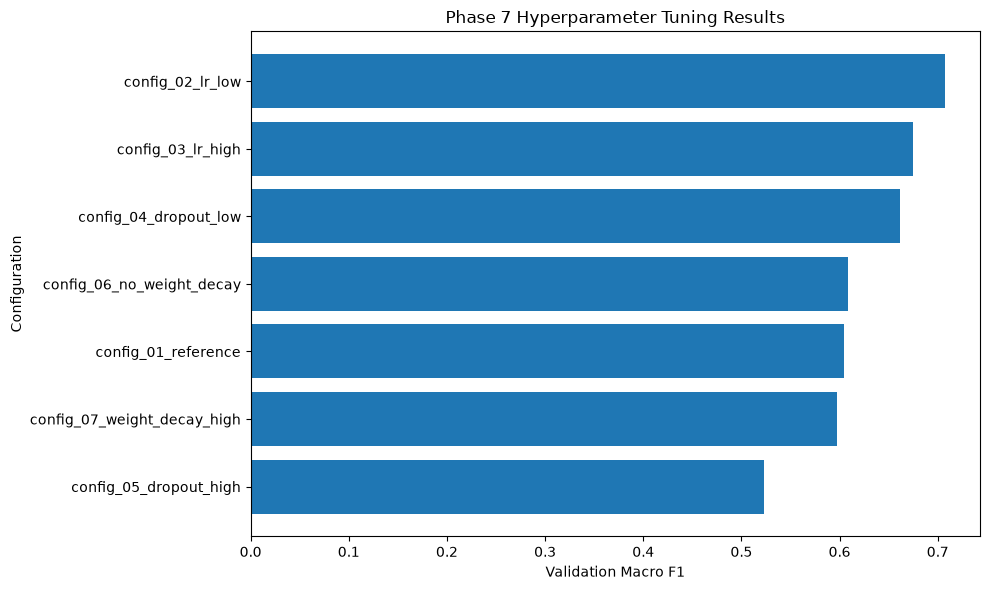

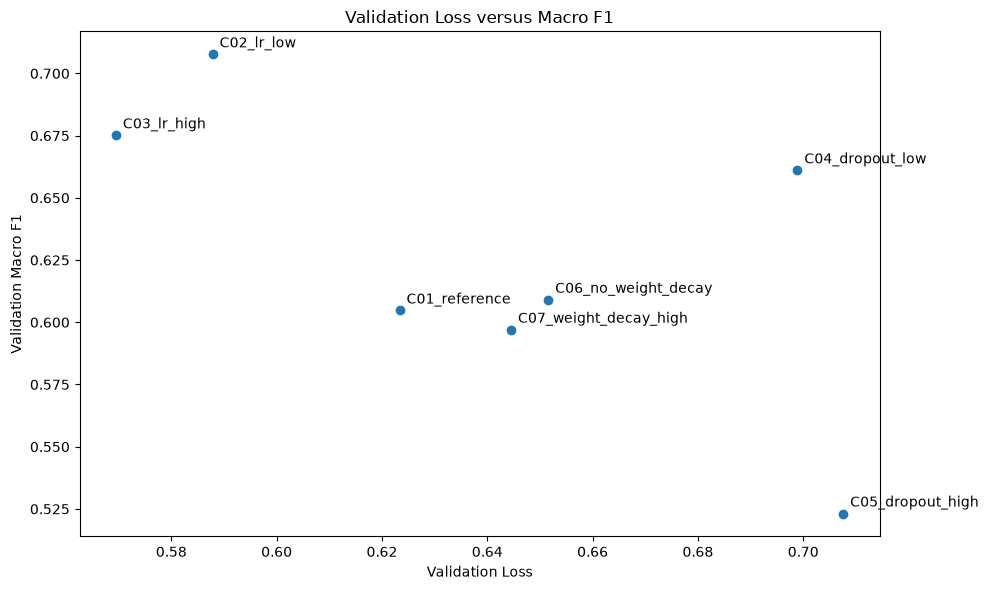

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/figures/validation_macro_f1_comparison.png
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/figures/validation_loss_vs_macro_f1.png


In [14]:
plot_df = ranked_results_df.sort_values(
    "validation_macro_f1",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df["experiment_id"],
    plot_df["validation_macro_f1"],
)
plt.xlabel("Validation Macro F1")
plt.ylabel("Configuration")
plt.title(
    "Phase 7 Hyperparameter Tuning Results"
)
plt.tight_layout()

macro_f1_plot_path = (
    FIGURES_DIR
    / "validation_macro_f1_comparison.png"
)

plt.savefig(
    macro_f1_plot_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(
    ranked_results_df["validation_loss"],
    ranked_results_df["validation_macro_f1"],
)

for _, row in ranked_results_df.iterrows():
    plt.annotate(
        row["experiment_id"].replace(
            "config_",
            "C",
        ),
        (
            row["validation_loss"],
            row["validation_macro_f1"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Validation Loss")
plt.ylabel("Validation Macro F1")
plt.title(
    "Validation Loss versus Macro F1"
)
plt.tight_layout()

loss_f1_plot_path = (
    FIGURES_DIR
    / "validation_loss_vs_macro_f1.png"
)

plt.savefig(
    loss_f1_plot_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Saved: {macro_f1_plot_path}")
print(f"Saved: {loss_f1_plot_path}")

In [15]:
reference_row = ranked_results_df.loc[
    ranked_results_df["experiment_id"]
    == "config_01_reference"
].iloc[0]

parameter_effect_rows = []

for _, row in ranked_results_df.iterrows():
    parameter_effect_rows.append(
        {
            "experiment_id": row["experiment_id"],
            "changed_parameter": row["changed_parameter"],
            "learning_rate": row["learning_rate"],
            "dropout": row["dropout"],
            "weight_decay": row["weight_decay"],
            "validation_macro_f1": (
                row["validation_macro_f1"]
            ),
            "macro_f1_change_from_reference": (
                row["validation_macro_f1"]
                - reference_row[
                    "validation_macro_f1"
                ]
            ),
        }
    )

parameter_effects_df = pd.DataFrame(
    parameter_effect_rows
)

parameter_effects_path = (
    RESULTS_DIR
    / "parameter_effects.csv"
)

parameter_effects_df.to_csv(
    parameter_effects_path,
    index=False,
)

display(
    parameter_effects_df.sort_values(
        "validation_macro_f1",
        ascending=False,
    )
)

,experiment_id,changed_parameter,learning_rate,dropout,weight_decay,validation_macro_f1,macro_f1_change_from_reference
0,config_02_lr_low,learning_rate,0.0003,0.5,0.0001,0.707682,0.102949
1,config_03_lr_high,learning_rate,0.0030,0.5,0.0001,0.675129,0.070397
2,config_04_dropout_low,dropout,0.0010,0.3,0.0001,0.661060,0.056328
3,config_06_no_weight_decay,weight_decay,0.0010,0.5,0.0000,0.609051,0.004319
4,config_01_reference,reference,0.0010,0.5,0.0001,0.604733,0.000000
5,config_07_weight_decay_high,weight_decay,0.0010,0.5,0.0010,0.597015,-0.007717
6,config_05_dropout_high,dropout,0.0010,0.7,0.0001,0.523148,-0.081585


In [16]:
best_checkpoint_source = Path(
    winner["checkpoint_path"]
)

best_history_source = Path(
    winner["history_path"]
)

best_predictions_source = Path(
    winner["predictions_path"]
)

BEST_TUNED_CHECKPOINT = (
    RESULTS_DIR
    / "best_tuned_model.pth"
)

BEST_TUNED_HISTORY = (
    RESULTS_DIR
    / "best_tuned_history.csv"
)

BEST_TUNED_PREDICTIONS = (
    RESULTS_DIR
    / "best_tuned_validation_predictions.csv"
)

BEST_TUNED_METADATA = (
    RESULTS_DIR
    / "best_tuned_model.json"
)

shutil.copy2(
    best_checkpoint_source,
    BEST_TUNED_CHECKPOINT,
)

shutil.copy2(
    best_history_source,
    BEST_TUNED_HISTORY,
)

shutil.copy2(
    best_predictions_source,
    BEST_TUNED_PREDICTIONS,
)

best_tuned_metadata = {
    "phase": 7,
    "model_family": "resnet18",
    "training_mode": TRAINING_MODE,
    "selection_split": "validation",
    "selection_metric": "validation_macro_f1",
    "selection_rule": [
        "highest validation Macro F1",
        "highest validation accuracy",
        "lowest validation loss",
    ],
    "test_set_used": False,
    "best_configuration": {
        "experiment_id": winner["experiment_id"],
        "learning_rate": float(
            winner["learning_rate"]
        ),
        "dropout": float(
            winner["dropout"]
        ),
        "weight_decay": float(
            winner["weight_decay"]
        ),
    },
    "validation_metrics": {
        "loss": float(
            winner["validation_loss"]
        ),
        "accuracy": float(
            winner["validation_accuracy"]
        ),
        "macro_precision": float(
            winner[
                "validation_macro_precision"
            ]
        ),
        "macro_recall": float(
            winner[
                "validation_macro_recall"
            ]
        ),
        "macro_f1": float(
            winner["validation_macro_f1"]
        ),
        "weighted_f1": float(
            winner["validation_weighted_f1"]
        ),
    },
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "resize_size": RESIZE_SIZE,
    "augmentation": "RandomCrop",
    "class_weights": (
        CLASS_WEIGHTS.tolist()
    ),
    "checkpoint_path": str(
        BEST_TUNED_CHECKPOINT
    ),
    "history_path": str(
        BEST_TUNED_HISTORY
    ),
    "predictions_path": str(
        BEST_TUNED_PREDICTIONS
    ),
}

with BEST_TUNED_METADATA.open(
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        best_tuned_metadata,
        output_file,
        indent=4,
    )

print(f"Saved: {BEST_TUNED_CHECKPOINT}")
print(f"Saved: {BEST_TUNED_HISTORY}")
print(f"Saved: {BEST_TUNED_PREDICTIONS}")
print(f"Saved: {BEST_TUNED_METADATA}")

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/best_tuned_model.pth
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/best_tuned_history.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/best_tuned_validation_predictions.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/best_tuned_model.json


In [23]:
phase_6_selection = read_json(
    PHASE_6_SELECTION_PATH
)


def find_metric_recursively(
    data,
    possible_keys: list[str],
):
    """
    Search nested dictionaries and lists for the first
    non-null metric matching one of the possible keys.
    """
    if isinstance(data, dict):
        for key in possible_keys:
            if key in data and data[key] is not None:
                try:
                    return float(data[key])
                except (TypeError, ValueError):
                    pass

        for value in data.values():
            result = find_metric_recursively(
                value,
                possible_keys,
            )

            if result is not None:
                return result

    elif isinstance(data, list):
        for item in data:
            result = find_metric_recursively(
                item,
                possible_keys,
            )

            if result is not None:
                return result

    return None


phase_6_macro_f1 = find_metric_recursively(
    phase_6_selection,
    possible_keys=[
        "validation_macro_f1",
        "best_validation_macro_f1",
        "val_macro_f1",
        "macro_f1",
    ],
)

assert phase_6_macro_f1 is not None, (
    "The Phase 6 validation Macro F1 could not be "
    "found. Inspect final_model.json before replacing "
    "the canonical model."
)

tuned_macro_f1 = float(
    winner["validation_macro_f1"]
)

replace_canonical_model = (
    tuned_macro_f1
    >= phase_6_macro_f1
)

CANONICAL_CHECKPOINT = (
    FINAL_MODEL_DIR
    / "best_model.pth"
)

CANONICAL_HISTORY = (
    FINAL_MODEL_DIR
    / "best_model_history.csv"
)

CANONICAL_METADATA = (
    FINAL_MODEL_DIR
    / "best_model.json"
)

if replace_canonical_model:
    shutil.copy2(
        BEST_TUNED_CHECKPOINT,
        CANONICAL_CHECKPOINT,
    )

    shutil.copy2(
        BEST_TUNED_HISTORY,
        CANONICAL_HISTORY,
    )

    canonical_metadata = {
        **best_tuned_metadata,
        "canonical_model_updated": True,
        "replaced_phase_6_candidate": True,
        "previous_phase_6_macro_f1": (
            phase_6_macro_f1
        ),
    }

    with CANONICAL_METADATA.open(
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(
            canonical_metadata,
            output_file,
            indent=4,
        )

    decision = (
        "The tuned ResNet18 became the canonical "
        "final candidate because its validation Macro F1 "
        f"({tuned_macro_f1:.4f}) exceeded the Phase 6 "
        f"candidate ({phase_6_macro_f1:.4f})."
    )

else:
    decision = (
        "The Phase 6 candidate remains canonical because "
        f"its validation Macro F1 "
        f"({phase_6_macro_f1:.4f}) was higher than the "
        f"best tuned ResNet18 "
        f"({tuned_macro_f1:.4f})."
    )

selection_decision = {
    "phase_6_validation_macro_f1": (
        phase_6_macro_f1
    ),
    "best_tuned_validation_macro_f1": (
        tuned_macro_f1
    ),
    "macro_f1_improvement": (
        tuned_macro_f1
        - phase_6_macro_f1
    ),
    "canonical_model_replaced": (
        replace_canonical_model
    ),
    "decision": decision,
}

with (
    RESULTS_DIR
    / "canonical_model_decision.json"
).open(
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        selection_decision,
        output_file,
        indent=4,
    )

print(decision)
display(selection_decision)

The tuned ResNet18 became the canonical final candidate because its validation Macro F1 (0.7077) exceeded the Phase 6 candidate (0.6497).


{'phase_6_validation_macro_f1': 0.6496500304321363,
 'best_tuned_validation_macro_f1': 0.7076817104980431,
 'macro_f1_improvement': 0.058031680065906754,
 'canonical_model_replaced': True,
 'decision': 'The tuned ResNet18 became the canonical final candidate because its validation Macro F1 (0.7077) exceeded the Phase 6 candidate (0.6497).'}

In [22]:
phase_6_selection = read_json(
    PHASE_6_SELECTION_PATH
)


def find_phase_6_macro_f1(
    metadata: dict,
):
    possible_direct_keys = [
        "validation_macro_f1",
        "best_validation_macro_f1",
        "val_macro_f1",
        "macro_f1",
    ]

    for key in possible_direct_keys:
        if key in metadata:
            value = metadata[key]

            if value is not None:
                return float(value)

    possible_nested_sections = [
        "validation_metrics",
        "metrics",
        "best_metrics",
        "selected_model",
        "final_model",
    ]

    possible_nested_keys = [
        "validation_macro_f1",
        "best_validation_macro_f1",
        "val_macro_f1",
        "macro_f1",
    ]

    for section_name in possible_nested_sections:
        section = metadata.get(
            section_name,
            {}
        )

        if not isinstance(section, dict):
            continue

        for key in possible_nested_keys:
            if key in section:
                value = section[key]

                if value is not None:
                    return float(value)

    return None


phase_6_macro_f1 = find_phase_6_macro_f1(
    phase_6_selection
)

print(
    "Phase 6 validation Macro F1:",
    phase_6_macro_f1,
)

assert phase_6_macro_f1 is not None, (
    "The Phase 6 validation Macro F1 could not be "
    "found. Inspect final_model.json before replacing "
    "the canonical model."
)

Phase 6 validation Macro F1: 0.6496500304321363


,precision,recall,f1-score,support
No Pain,0.886139,0.881773,0.883951,203.000000
Moderate Pain,0.623188,0.641791,0.632353,67.000000
Severe Pain,0.613636,0.600000,0.606742,45.000000
accuracy,0.790476,0.790476,0.790476,0.790476
macro avg,0.707654,0.707855,0.707682,315.000000
weighted avg,0.791281,0.790476,0.790835,315.000000


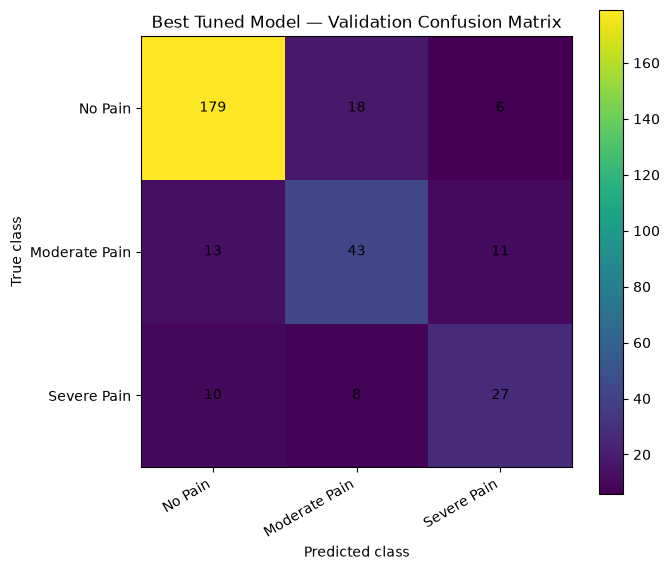

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/best_tuned_validation_classification_report.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/figures/best_tuned_validation_confusion_matrix.png


In [18]:
best_predictions_df = pd.read_csv(
    BEST_TUNED_PREDICTIONS
)

report_dictionary = classification_report(
    best_predictions_df["target"],
    best_predictions_df["prediction"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(
    report_dictionary
).transpose()

report_path = (
    RESULTS_DIR
    / "best_tuned_validation_classification_report.csv"
)

report_df.to_csv(
    report_path
)

display(report_df)

matrix = confusion_matrix(
    best_predictions_df["target"],
    best_predictions_df["prediction"],
    labels=list(range(NUM_CLASSES)),
)

fig, axis = plt.subplots(
    figsize=(7, 6)
)

image = axis.imshow(matrix)

axis.set_xticks(
    range(NUM_CLASSES),
    labels=CLASS_NAMES,
    rotation=30,
    ha="right",
)
axis.set_yticks(
    range(NUM_CLASSES),
    labels=CLASS_NAMES,
)
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")
axis.set_title(
    "Best Tuned Model — Validation Confusion Matrix"
)

for row_index in range(NUM_CLASSES):
    for column_index in range(NUM_CLASSES):
        axis.text(
            column_index,
            row_index,
            str(
                matrix[
                    row_index,
                    column_index,
                ]
            ),
            ha="center",
            va="center",
        )

fig.colorbar(
    image,
    ax=axis,
)
fig.tight_layout()

confusion_matrix_path = (
    FIGURES_DIR
    / "best_tuned_validation_confusion_matrix.png"
)

fig.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(f"Saved: {report_path}")
print(f"Saved: {confusion_matrix_path}")

In [19]:
runner_up = ranked_results_df.iloc[1]

macro_f1_gain = (
    float(winner["validation_macro_f1"])
    - float(
        reference_row[
            "validation_macro_f1"
        ]
    )
)

runner_up_margin = (
    float(winner["validation_macro_f1"])
    - float(
        runner_up[
            "validation_macro_f1"
        ]
    )
)

conclusion = (
    f"The best Phase 7 configuration was "
    f"`{winner['experiment_id']}` with learning rate "
    f"{winner['learning_rate']:.1e}, dropout "
    f"{winner['dropout']:.2f}, and weight decay "
    f"{winner['weight_decay']:.1e}. It achieved a "
    f"validation Macro F1 of "
    f"{winner['validation_macro_f1']:.4f}, validation "
    f"accuracy of {winner['validation_accuracy']:.4f}, "
    f"and validation loss of "
    f"{winner['validation_loss']:.4f}. Its Macro F1 "
    f"change relative to the reference configuration was "
    f"{macro_f1_gain:+.4f}, and its margin over the "
    f"second-ranked tuned configuration was "
    f"{runner_up_margin:+.4f}. {decision} "
    f"The test set remained untouched."
)

display(
    Markdown(
        "### Phase 7 conclusion\n\n"
        + conclusion
    )
)

conclusion_path = (
    RESULTS_DIR
    / "phase_7_conclusion.txt"
)

conclusion_path.write_text(
    conclusion,
    encoding="utf-8",
)

print(f"Saved: {conclusion_path}")

### Phase 7 conclusion

The best Phase 7 configuration was `config_02_lr_low` with learning rate 3.0e-04, dropout 0.50, and weight decay 1.0e-04. It achieved a validation Macro F1 of 0.7077, validation accuracy of 0.7905, and validation loss of 0.5878. Its Macro F1 change relative to the reference configuration was +0.1029, and its margin over the second-ranked tuned configuration was +0.0326. The tuned ResNet18 became the canonical final candidate. The test set remained untouched.

Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/hyperparameter_tuning/phase_7_conclusion.txt


In [20]:
expected_outputs = [
    RESULTS_DIR / "tuning_results_unsorted.csv",
    RESULTS_DIR / "tuning_rankings.csv",
    RESULTS_DIR / "parameter_effects.csv",
    RESULTS_DIR / "best_tuned_model.pth",
    RESULTS_DIR / "best_tuned_history.csv",
    RESULTS_DIR / "best_tuned_model.json",
    RESULTS_DIR / "best_tuned_validation_predictions.csv",
    RESULTS_DIR / "best_tuned_validation_classification_report.csv",
    RESULTS_DIR / "canonical_model_decision.json",
    RESULTS_DIR / "phase_7_conclusion.txt",
    FIGURES_DIR / "validation_macro_f1_comparison.png",
    FIGURES_DIR / "validation_loss_vs_macro_f1.png",
    FIGURES_DIR / "best_tuned_validation_confusion_matrix.png",
]

missing_outputs = [
    path
    for path in expected_outputs
    if not path.exists()
]

assert not missing_outputs, (
    "Missing expected outputs:\n"
    + "\n".join(
        str(path)
        for path in missing_outputs
    )
)

print(
    "All expected Phase 7 outputs were created."
)
print(
    f"Completed tuning experiments: "
    f"{len(TUNING_CONFIGURATIONS)}"
)
print("Test set accessed: False")

All expected Phase 7 outputs were created.
Completed tuning experiments: 7
Test set accessed: False
